In [1]:
!unzip images.zip

Archive:  images.zip
   creating: images/
   creating: images/algorithms/
   creating: images/algorithms/alg1/
  inflating: images/algorithms/alg1/rdb005ll.tif  
  inflating: images/algorithms/alg1/rdb023ll.tif  
  inflating: images/algorithms/alg1/rdb025ll.tif  
  inflating: images/algorithms/alg1/rdb028rl.tif  
   creating: images/algorithms/alg2/
  inflating: images/algorithms/alg2/rdb005ll.tif  
  inflating: images/algorithms/alg2/rdb023ll.tif  
  inflating: images/algorithms/alg2/rdb025ll.tif  
  inflating: images/algorithms/alg2/rdb028rl.tif  
   creating: images/algorithms/alg3/
  inflating: images/algorithms/alg3/rdb005ll.tif  
  inflating: images/algorithms/alg3/rdb023ll.tif  
  inflating: images/algorithms/alg3/rdb025ll.tif  
  inflating: images/algorithms/alg3/rdb028rl.tif  
   creating: images/algorithms/alg4/
  inflating: images/algorithms/alg4/rdb005ll.tif  
  inflating: images/algorithms/alg4/rdb023ll.tif  
  inflating: images/algorithms/alg4/rdb025ll.tif  
  inflating: 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import cv2
import os

In [3]:
GT_DIR = os.path.join("images", "ground_truth")
ALGO_DIR = os.path.join("images", "algorithms")

In [4]:
def load_images_from_folder(folder_path):
    images = []
    filenames = []
    for filename in sorted(os.listdir(folder_path)):
        img_path = os.path.join(folder_path, filename)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            images.append(img)
            filenames.append(filename)
    return images, filenames

In [5]:
def prepare_data_for_roc(gt_images, algo_images, binarization_threshold = 127):
    gt_array = np.array(gt_images)
    algo_array = np.array(algo_images)

    gt_flat = gt_array.flatten()
    algo_flat = algo_array.flatten()

    y_true = (gt_flat > binarization_threshold).astype(int)

    y_scores = algo_flat / 255.0

    return y_true, y_scores

In [6]:
def calculate_roc_manual(y_true, y_scores):
    thresholds = np.unique(y_scores)[::-1]
    thresholds = np.insert(thresholds, 0, thresholds[0] + 0.1)
    tpr_list = []
    fpr_list = []

    P = np.sum(y_true == 1)
    N = np.sum(y_true == 0)

    for thresh in thresholds:
        y_pred = (y_scores >= thresh).astype(int)

        TP = np.sum((y_pred == 1) & (y_true == 1))

        FP = np.sum((y_pred == 1) & (y_true == 0))

        TPR = TP / P if P > 0 else 0
        FPR = FP / N if N > 0 else 0

        tpr_list.append(TPR)
        fpr_list.append(FPR)

    return np.array(fpr_list), np.array(tpr_list), thresholds

In [7]:
def calculate_auc_manual(fpr, tpr):
    auc = 0
    for i in range(1, len(fpr)):
        width = fpr[i] - fpr[i-1]
        avg_height = (tpr[i] + tpr[i-1]) / 2.0
        auc += width * avg_height

    return auc

In [8]:
def calculate_jaccard_dice_manual(y_true, y_scores, best_thresh):
    y_pred = (y_scores >= best_thresh).astype(int)

    TP = np.sum((y_pred == 1) & (y_true == 1))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))

    jaccard = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0.0
    dice = (2 * TP) / ((2 * TP) + FP + FN) if ((2 * TP) + FP + FN) > 0 else 0.0

    return jaccard, dice

In [9]:
def plot_roc_curve(title, y_true, y_scores, auc_manual, auc_sklearn, fpr_manual, tpr_manual, fpr_sklearn, tpr_sklearn, best_thresh, optimal_idx, output_jaccard_and_dice):
    print(f"--- {title} ---")
    print(f"Manual AUC: {auc_manual:.4f}")
    print(f"Sklearn AUC: {auc_sklearn:.4f}")
    print(f"Best Threshold: {best_thresh:.4f}")
    if output_jaccard_and_dice:
        jaccard_index, dice_coeffient = calculate_jaccard_dice_manual(y_true, y_scores, best_thresh)
        print(f"Jaccard Index: {jaccard_index:.4f}")
        print(f"Dice Coeffient: {dice_coeffient:.4f}")

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_manual, tpr_manual, color='blue', lw=5, alpha=0.5,
             label=f'Manual ROC (AUC = {auc_manual:.4f})')
    plt.plot(fpr_sklearn, tpr_sklearn, color='red', lw=2, linestyle='--',
             label=f'Sklearn ROC (AUC = {auc_sklearn:.4f})')
    plt.plot(fpr_manual[optimal_idx], tpr_manual[optimal_idx], marker='o',
             color='green', markersize=8, label=f'Best Threshold ({best_thresh:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle=':', label='Random Guess')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'ROC Curve: {title}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

In [10]:
def evaluate_and_plot(y_true, y_scores, title, output_jaccard_and_dice):
    fpr_manual, tpr_manual, thresholds = calculate_roc_manual(y_true, y_scores)
    auc_manual = calculate_auc_manual(fpr_manual, tpr_manual)

    optimal_idx = np.argmax(tpr_manual - fpr_manual)
    best_thresh = thresholds[optimal_idx]

    fpr_sklearn, tpr_sklearn, _ = roc_curve(y_true, y_scores)
    auc_sklearn = auc(fpr_sklearn, tpr_sklearn)

    plot_roc_curve(title, y_true, y_scores, auc_manual, auc_sklearn, fpr_manual, tpr_manual, fpr_sklearn, tpr_sklearn, best_thresh, optimal_idx, output_jaccard_and_dice)

In [11]:
def evaluate_algorithms(gt_path, algo_path, algo_name):
    gt_images, gt_filenames = load_images_from_folder(gt_path)
    algo_images, _ = load_images_from_folder(algo_path)

    if len(gt_images) == 0 or len(algo_images) == 0:
        return

    print(f"{'='*50}")
    print(f"{'-'*15} {algo_name} evaluation {'-'*15}")
    print(f"{'='*50}\n")

    print(">>> per-image evaluation <<<\n")
    for gt_img, algo_img, filename in zip(gt_images, algo_images, gt_filenames):
        y_true_img, y_scores_img = prepare_data_for_roc([gt_img], [algo_img])

        if np.sum(y_true_img) == 0:
            print(f"--- can't plot roc curve for image {filename} ---")
            continue

        evaluate_and_plot(y_true_img, y_scores_img, f"image {filename} - {algo_name}", False)


    print(f"{'='*50}")
    print(f">>> per-algorithm evaluation for {algo_name} <<<")
    print(f"{'='*50}\n")

    y_true_all, y_scores_all = prepare_data_for_roc(gt_images, algo_images)
    evaluate_and_plot(y_true_all, y_scores_all, f" overall - {algo_name} evaluation", True)

--------------- alg1 evaluation ---------------

>>> per-image evaluation <<<

--- image rdb005ll.tif - alg1 ---
Manual AUC: 0.7488
Sklearn AUC: 0.7488
Best Threshold: 0.0039


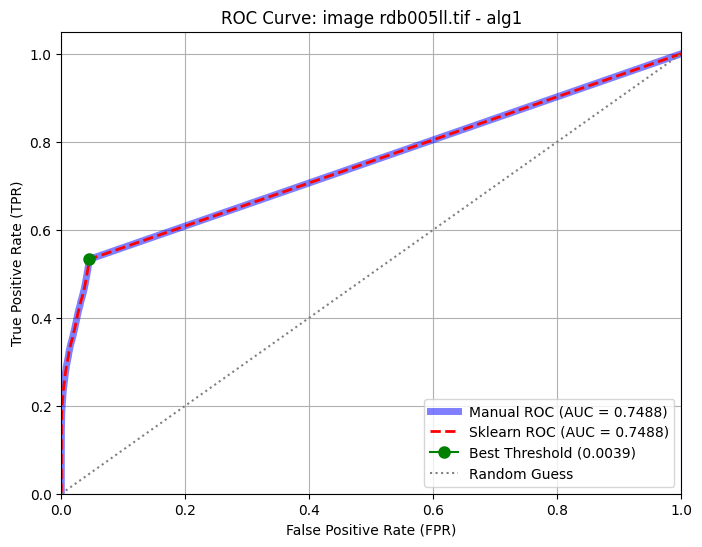

--- image rdb023ll.tif - alg1 ---
Manual AUC: 0.4586
Sklearn AUC: 0.4586
Best Threshold: 0.7471


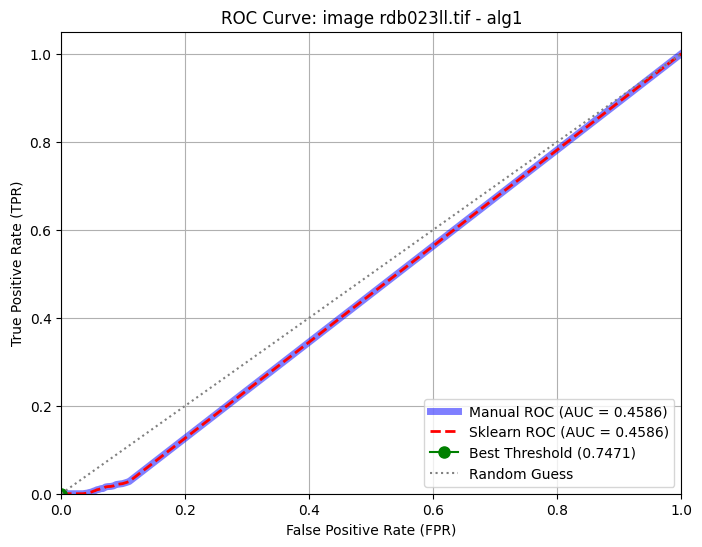

--- image rdb025ll.tif - alg1 ---
Manual AUC: 0.8393
Sklearn AUC: 0.8393
Best Threshold: 0.0039


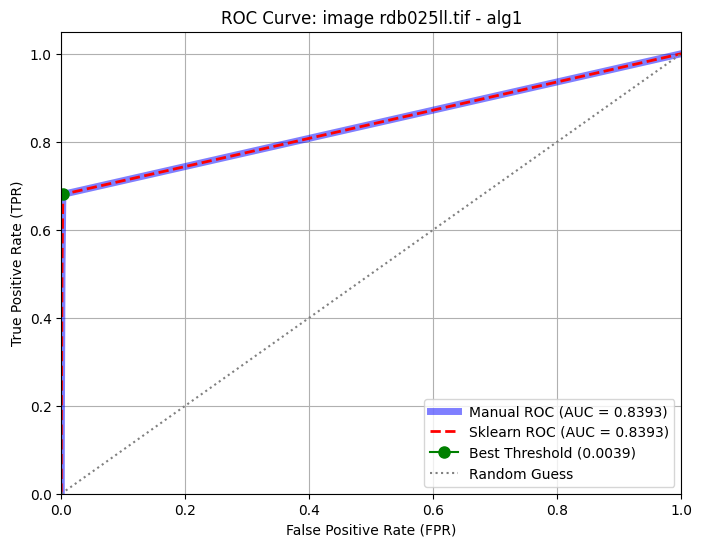

--- image rdb028rl.tif - alg1 ---
Manual AUC: 0.8632
Sklearn AUC: 0.8632
Best Threshold: 0.0039


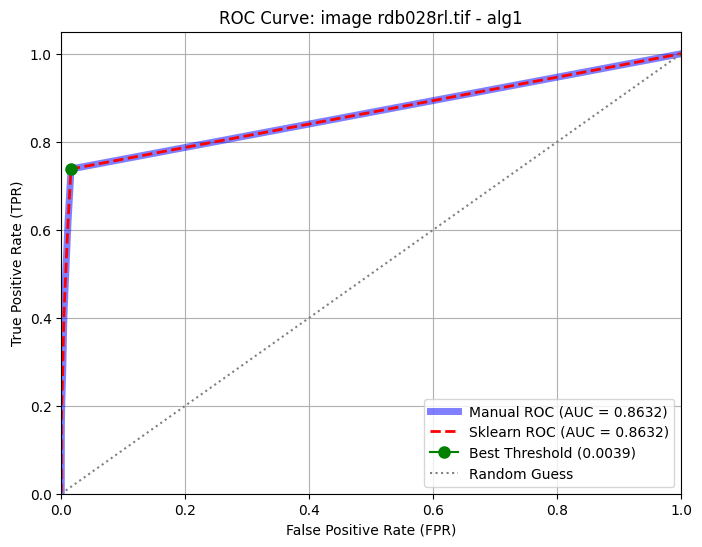

>>> per-algorithm evaluation for alg1 <<<

---  overall - alg1 evaluation ---
Manual AUC: 0.7906
Sklearn AUC: 0.7906
Best Threshold: 0.0039
Jaccard Index: 0.1324
Dice Coeffient: 0.2338


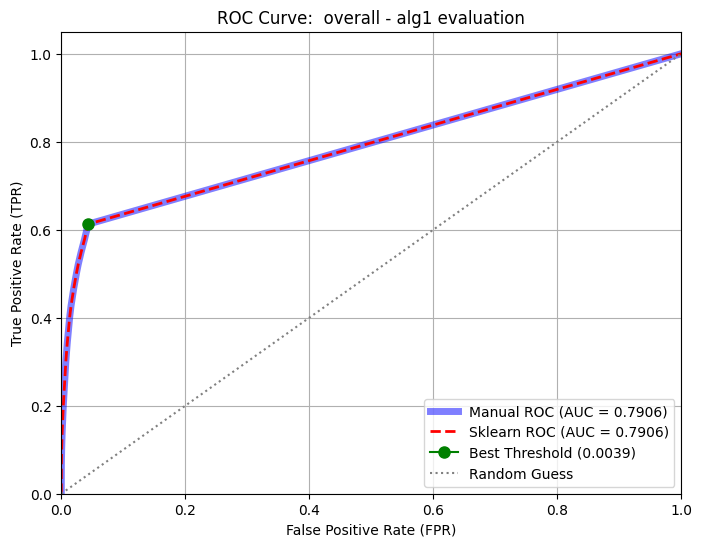

--------------- alg2 evaluation ---------------

>>> per-image evaluation <<<

--- image rdb005ll.tif - alg2 ---
Manual AUC: 0.8645
Sklearn AUC: 0.8645
Best Threshold: 0.2588


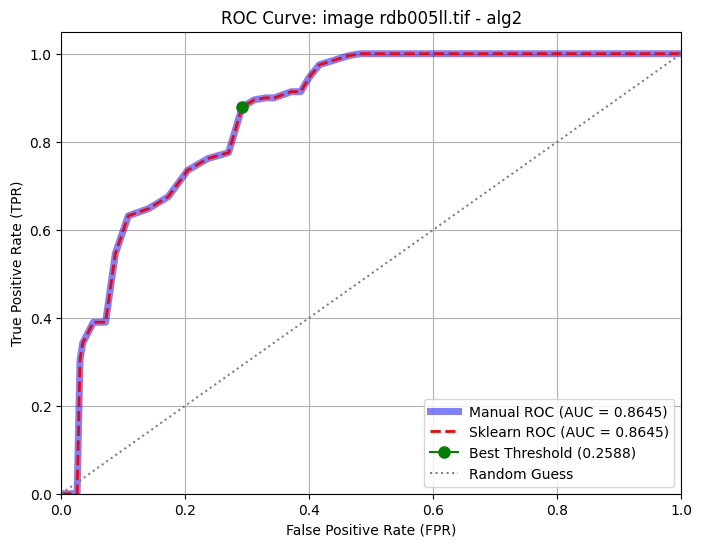

--- image rdb023ll.tif - alg2 ---
Manual AUC: 0.9669
Sklearn AUC: 0.9669
Best Threshold: 0.4196


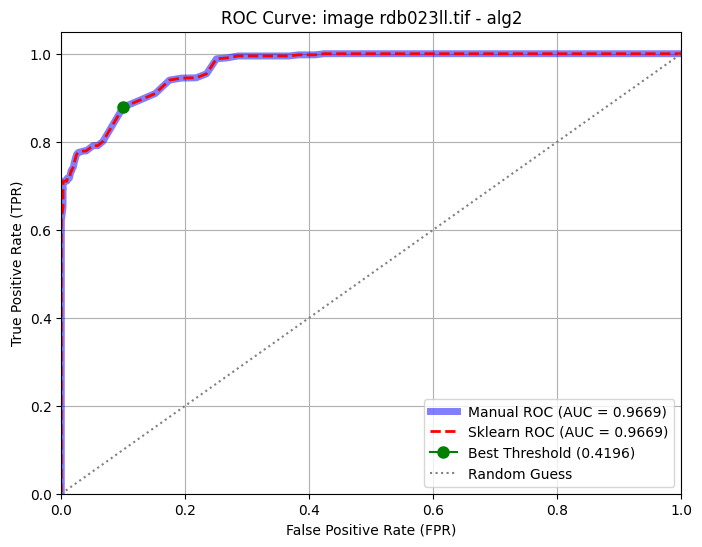

--- image rdb025ll.tif - alg2 ---
Manual AUC: 0.8373
Sklearn AUC: 0.8373
Best Threshold: 0.3608


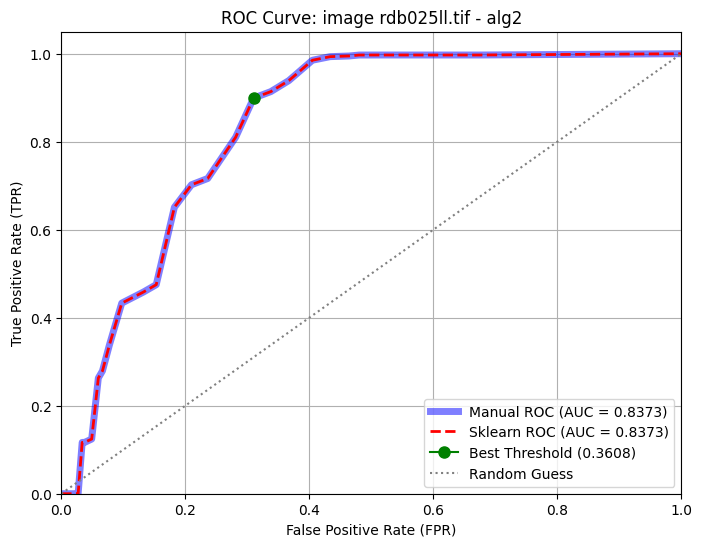

--- image rdb028rl.tif - alg2 ---
Manual AUC: 0.9075
Sklearn AUC: 0.9075
Best Threshold: 0.3804


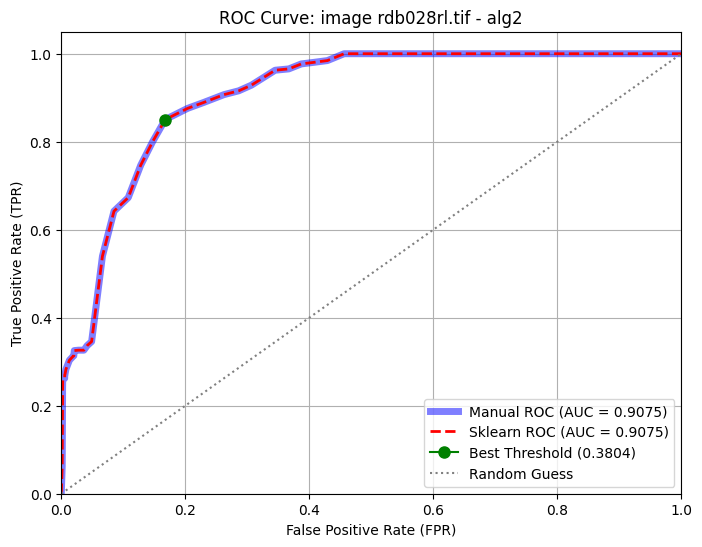

>>> per-algorithm evaluation for alg2 <<<

---  overall - alg2 evaluation ---
Manual AUC: 0.8772
Sklearn AUC: 0.8772
Best Threshold: 0.3216
Jaccard Index: 0.0357
Dice Coeffient: 0.0689


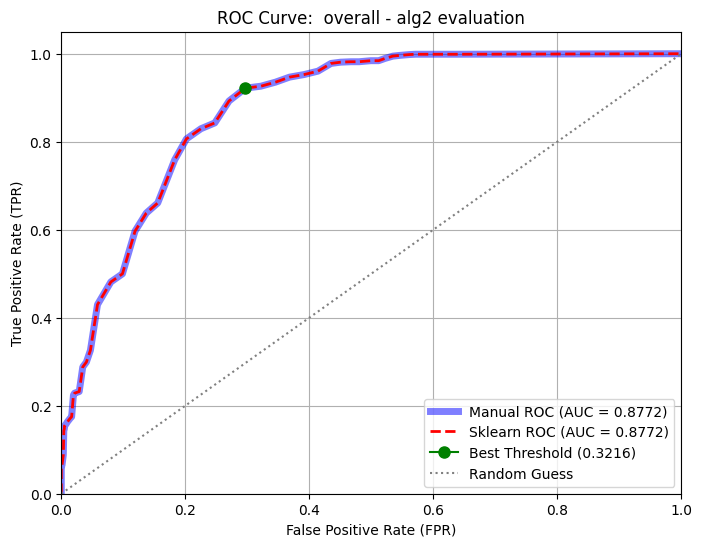

--------------- alg3 evaluation ---------------

>>> per-image evaluation <<<

--- image rdb005ll.tif - alg3 ---
Manual AUC: 0.9482
Sklearn AUC: 0.9482
Best Threshold: 0.0353


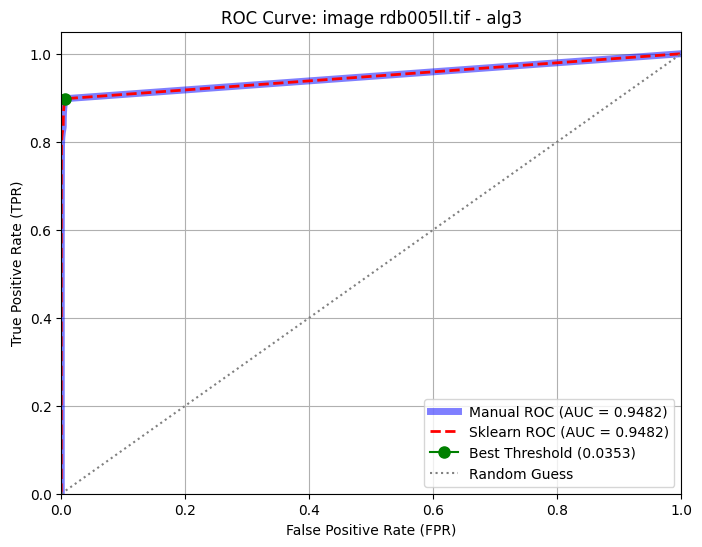

--- image rdb023ll.tif - alg3 ---
Manual AUC: 0.5000
Sklearn AUC: 0.5000
Best Threshold: 0.1000


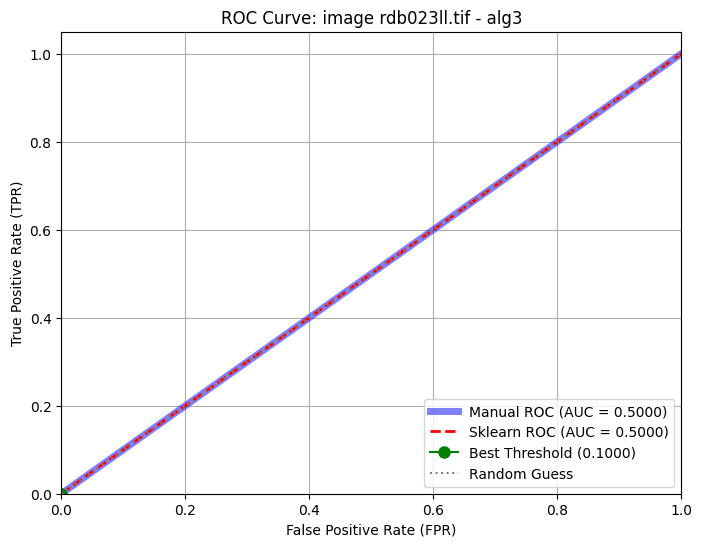

--- image rdb025ll.tif - alg3 ---
Manual AUC: 0.8822
Sklearn AUC: 0.8822
Best Threshold: 0.0196


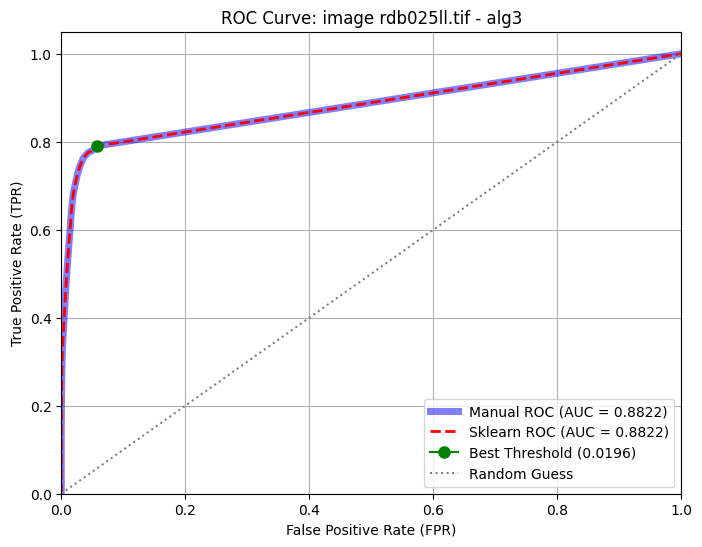

--- image rdb028rl.tif - alg3 ---
Manual AUC: 0.9485
Sklearn AUC: 0.9485
Best Threshold: 0.0353


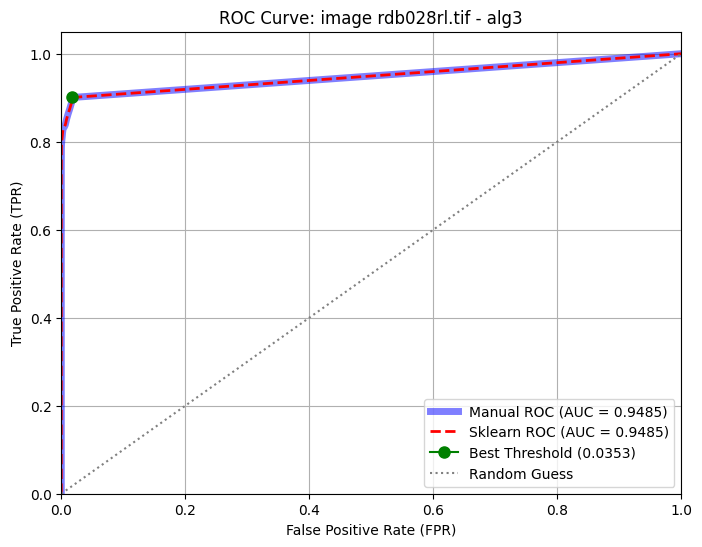

>>> per-algorithm evaluation for alg3 <<<

---  overall - alg3 evaluation ---
Manual AUC: 0.8812
Sklearn AUC: 0.8812
Best Threshold: 0.0196
Jaccard Index: 0.2687
Dice Coeffient: 0.4235


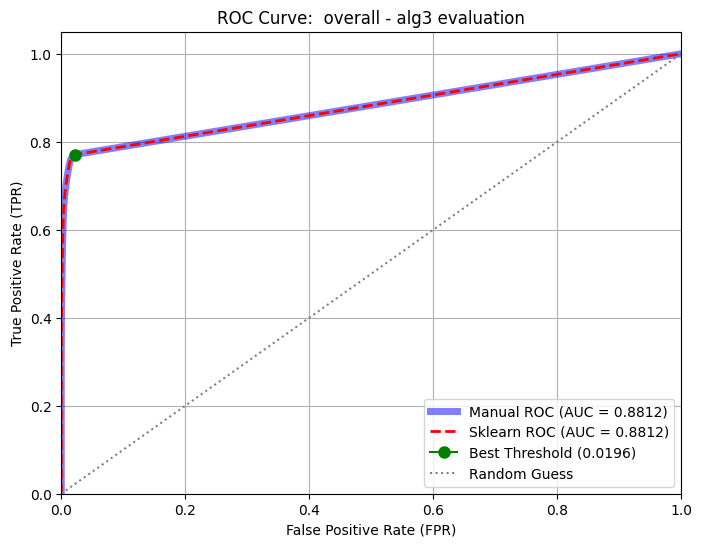

--------------- alg4 evaluation ---------------

>>> per-image evaluation <<<

--- image rdb005ll.tif - alg4 ---
Manual AUC: 0.8938
Sklearn AUC: 0.8938
Best Threshold: 0.0039


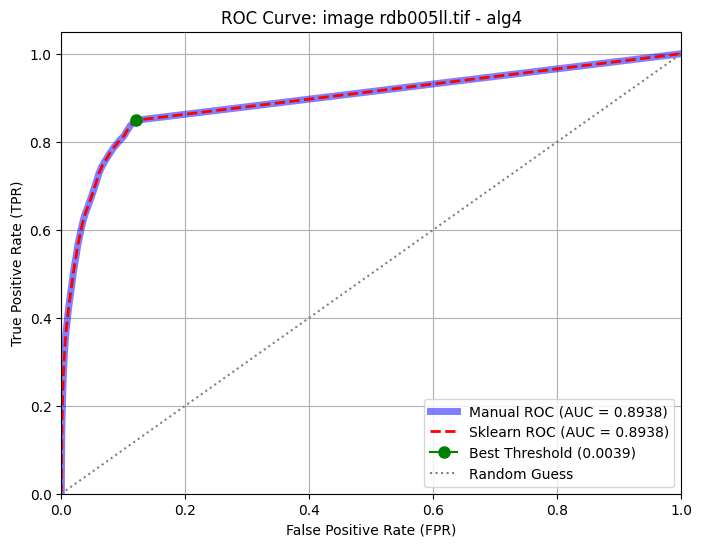

--- image rdb023ll.tif - alg4 ---
Manual AUC: 0.9581
Sklearn AUC: 0.9581
Best Threshold: 0.0510


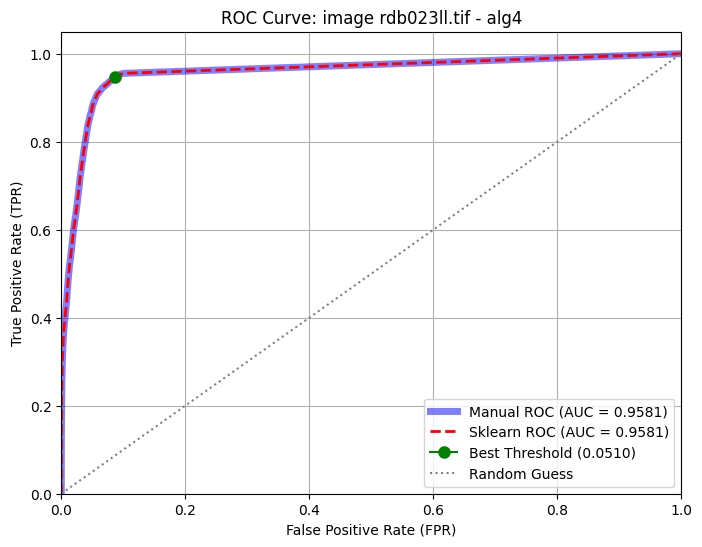

--- image rdb025ll.tif - alg4 ---
Manual AUC: 0.7433
Sklearn AUC: 0.7433
Best Threshold: 0.0039


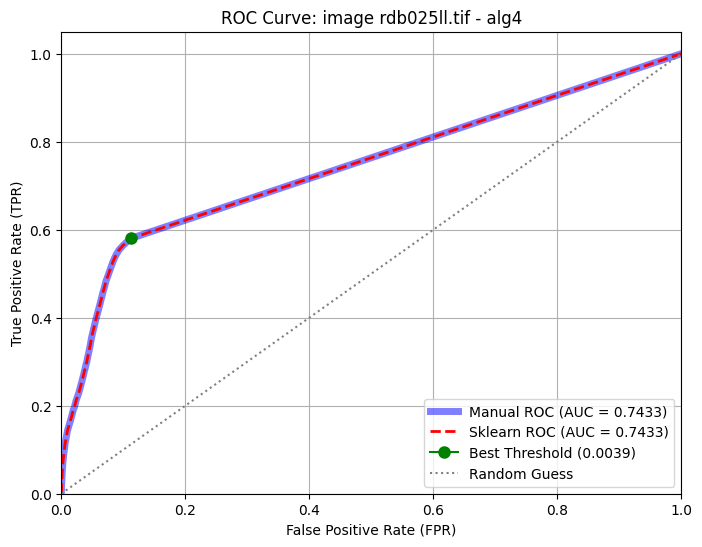

--- image rdb028rl.tif - alg4 ---
Manual AUC: 0.9623
Sklearn AUC: 0.9623
Best Threshold: 0.0039


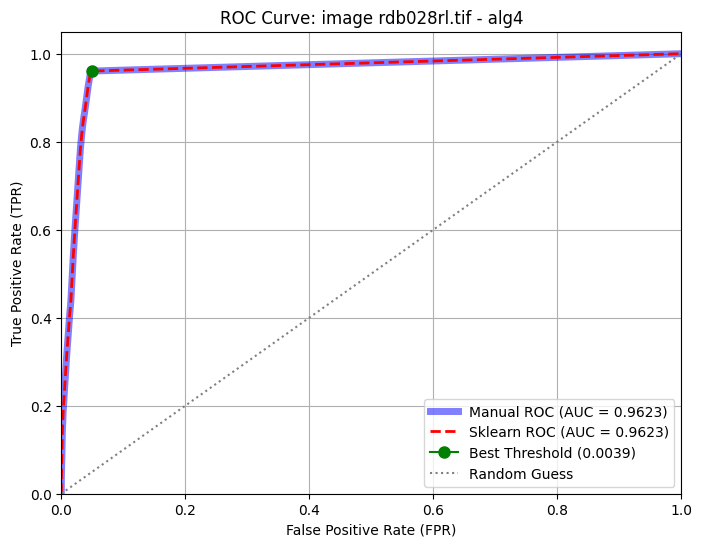

>>> per-algorithm evaluation for alg4 <<<

---  overall - alg4 evaluation ---
Manual AUC: 0.8619
Sklearn AUC: 0.8619
Best Threshold: 0.0039
Jaccard Index: 0.0877
Dice Coeffient: 0.1613


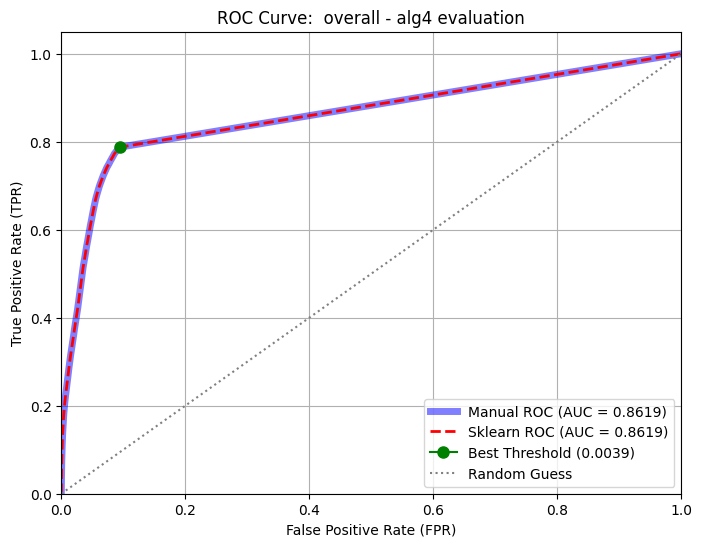

--------------- alg5 evaluation ---------------

>>> per-image evaluation <<<

--- image rdb005ll.tif - alg5 ---
Manual AUC: 0.7426
Sklearn AUC: 0.7426
Best Threshold: 0.2000


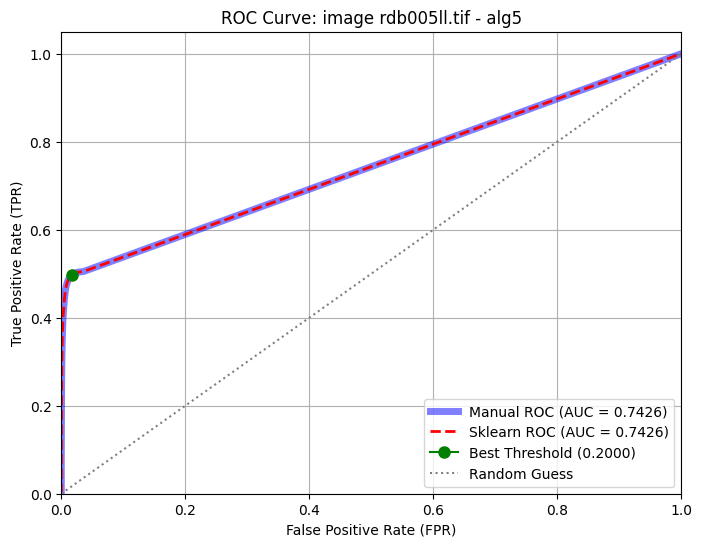

--- image rdb023ll.tif - alg5 ---
Manual AUC: 0.4837
Sklearn AUC: 0.4837
Best Threshold: 1.1000


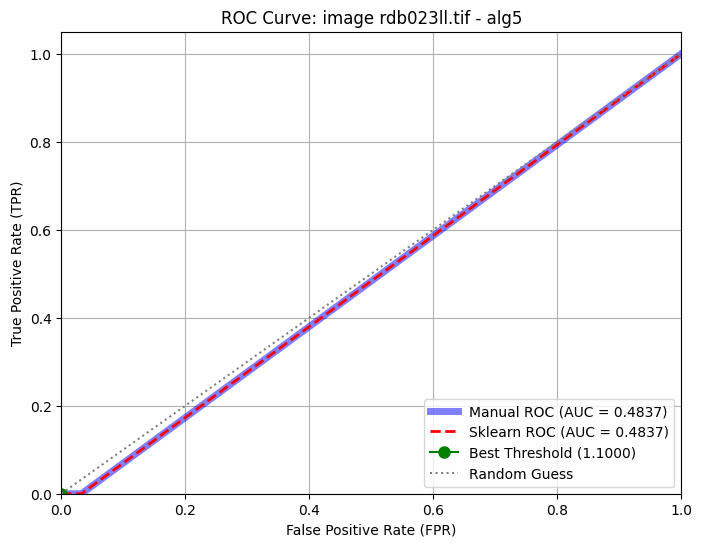

--- image rdb025ll.tif - alg5 ---
Manual AUC: 0.7543
Sklearn AUC: 0.7543
Best Threshold: 0.1412


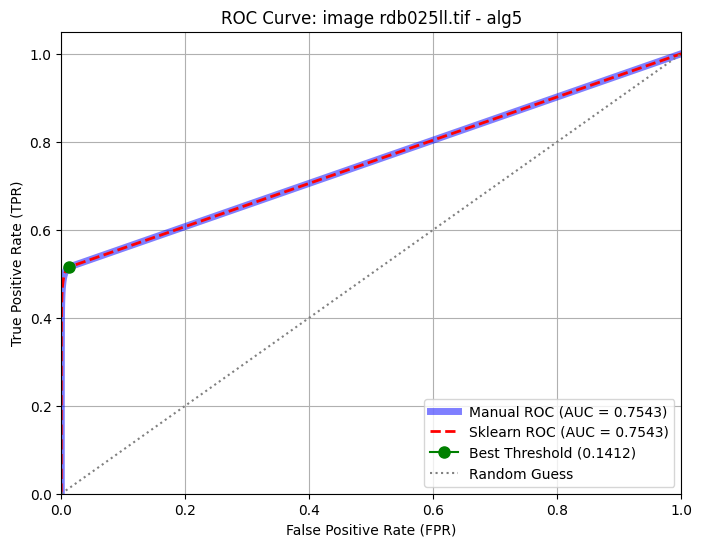

--- image rdb028rl.tif - alg5 ---
Manual AUC: 0.8002
Sklearn AUC: 0.8002
Best Threshold: 0.2784


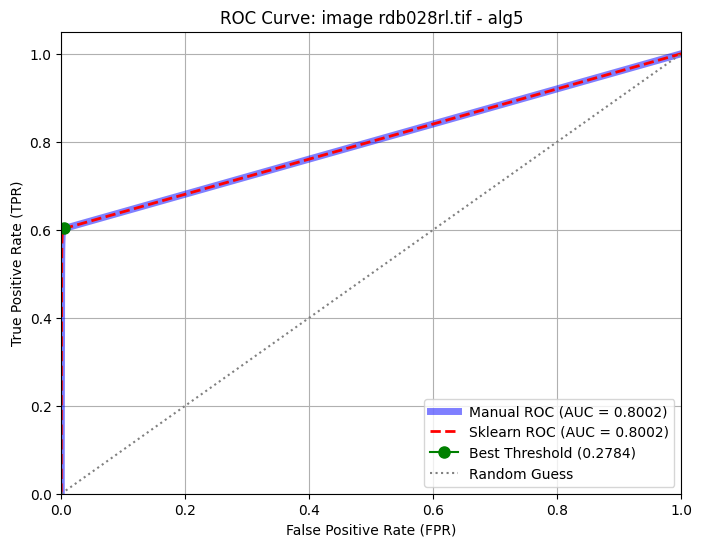

>>> per-algorithm evaluation for alg5 <<<

---  overall - alg5 evaluation ---
Manual AUC: 0.7405
Sklearn AUC: 0.7405
Best Threshold: 0.1804
Jaccard Index: 0.1920
Dice Coeffient: 0.3221


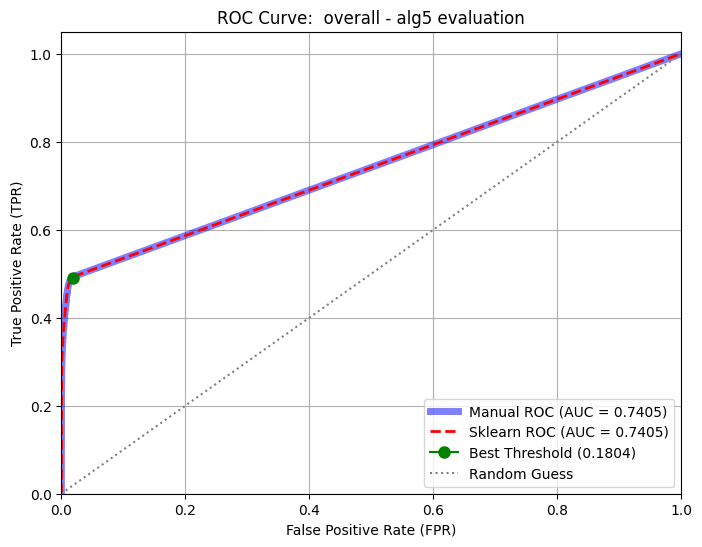

--------------- alg6 evaluation ---------------

>>> per-image evaluation <<<

--- image rdb005ll.tif - alg6 ---
Manual AUC: 0.9259
Sklearn AUC: 0.9259
Best Threshold: 0.0157


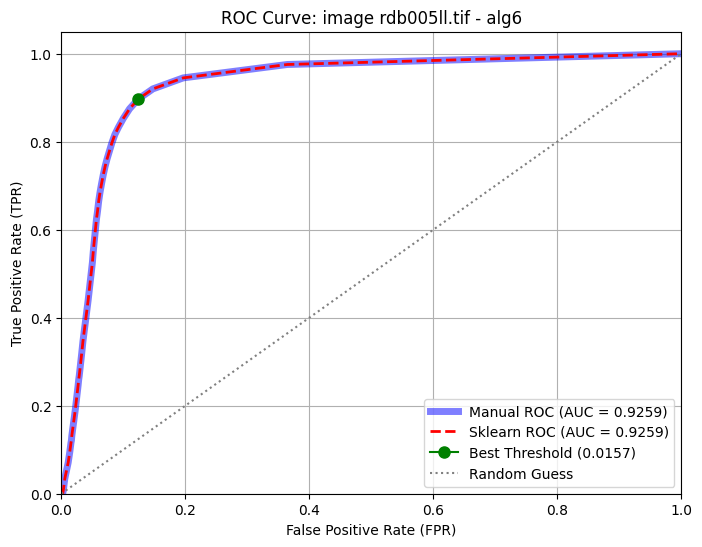

--- image rdb023ll.tif - alg6 ---
Manual AUC: 0.9187
Sklearn AUC: 0.9187
Best Threshold: 0.0196


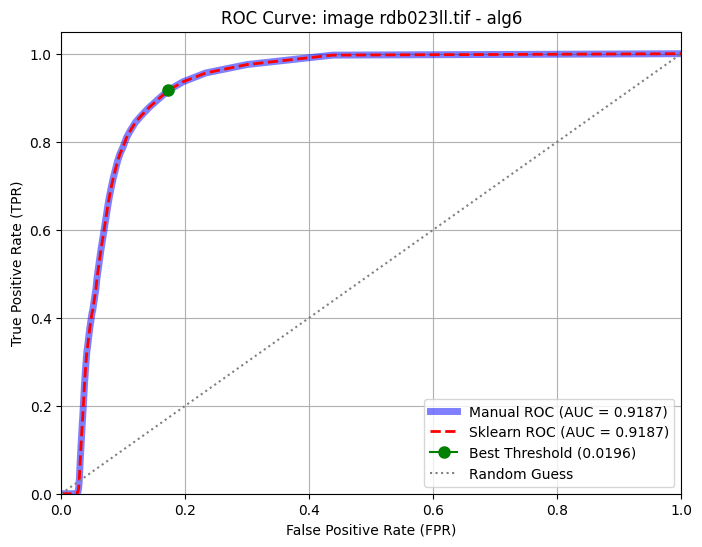

--- image rdb025ll.tif - alg6 ---
Manual AUC: 0.8811
Sklearn AUC: 0.8811
Best Threshold: 0.0275


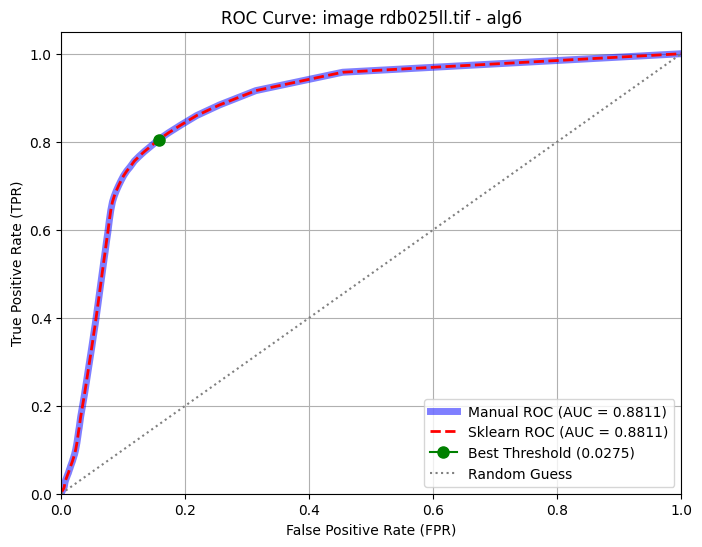

--- image rdb028rl.tif - alg6 ---
Manual AUC: 0.9087
Sklearn AUC: 0.9087
Best Threshold: 0.0196


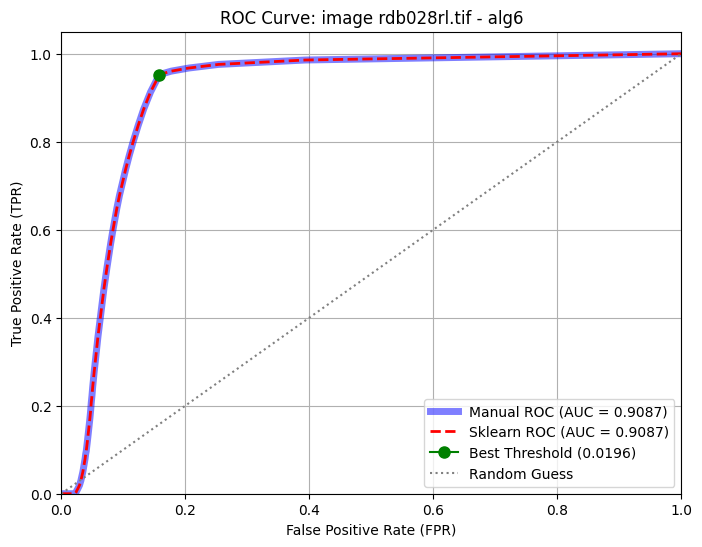

>>> per-algorithm evaluation for alg6 <<<

---  overall - alg6 evaluation ---
Manual AUC: 0.9044
Sklearn AUC: 0.9044
Best Threshold: 0.0196
Jaccard Index: 0.0625
Dice Coeffient: 0.1177


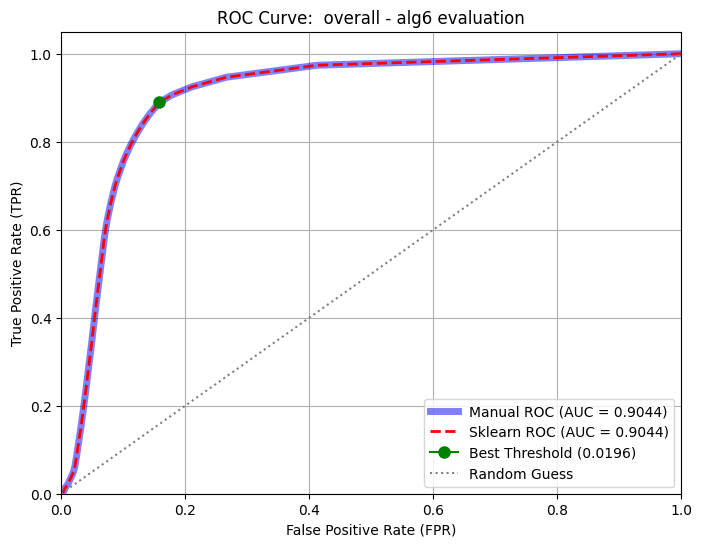

In [12]:
if os.path.exists(ALGO_DIR) and os.path.exists(GT_DIR):
    algorithms = [d for d in os.listdir(ALGO_DIR) if os.path.isdir(os.path.join(ALGO_DIR, d))]

    for algo_name in sorted(algorithms):
        algo_path = os.path.join(ALGO_DIR, algo_name)
        evaluate_algorithms(GT_DIR, algo_path, algo_name)

Generating overall comparison plot...


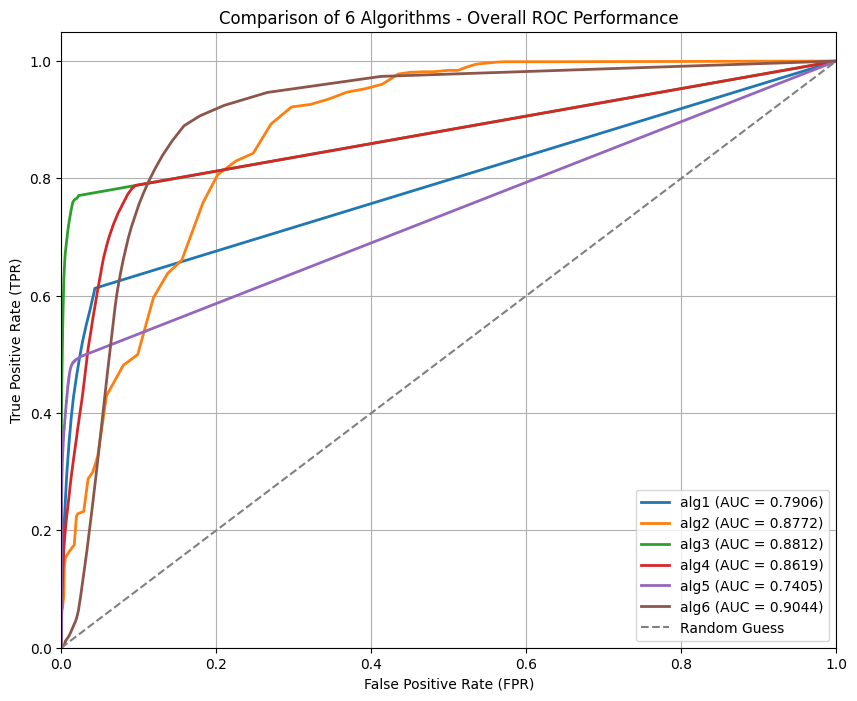

In [13]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Initialize the figure for the combined plot
plt.figure(figsize=(10, 8))

# Identify all algorithm folders inside ALGO_DIR
algorithms = sorted([d for d in os.listdir(ALGO_DIR) if os.path.isdir(os.path.join(ALGO_DIR, d))])

print("Generating overall comparison plot...")

for algo_name in algorithms:
    algo_path = os.path.join(ALGO_DIR, algo_name)

    # Load the ground truth and current algorithm's images
    gt_images, _ = load_images_from_folder(GT_DIR)
    algo_images, _ = load_images_from_folder(algo_path)

    # Skip if folders are empty
    if not gt_images or not algo_images:
        continue

    # Combine all pixels into one dataset for the 'overall' behavior
    y_true_all, y_scores_all = prepare_data_for_roc(gt_images, algo_images)

    # Calculate the ROC curve and AUC using sklearn
    fpr, tpr, _ = roc_curve(y_true_all, y_scores_all)
    roc_auc = auc(fpr, tpr)

    # Plot the curve for this specific algorithm
    plt.plot(fpr, tpr, lw=2, label=f'{algo_name} (AUC = {roc_auc:.4f})')

# Add the 'Random Guess' baseline diagonal
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')

# Finalize plot labels and formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Comparison of 6 Algorithms - Overall ROC Performance')
plt.legend(loc="lower right")
plt.grid(True)

# Display the final combined plot
plt.show()

best algorithm is 6

In [15]:
def calculate_hausdorff_manual(y_true_mask, y_pred_mask):
    # 1. Get coordinates (x, y) of all '1' pixels for both shapes
    coords_true = np.argwhere(y_true_mask == 1)
    coords_pred = np.argwhere(y_pred_mask == 1)

    # Handle cases where one mask might be empty
    if len(coords_true) == 0 or len(coords_pred) == 0:
        return 0.0

    def directed_hausdorff(set_a, set_b):
        max_dist = 0
        for a in set_a:
            # Find minimum distance from point 'a' to any point in set_b
            # Using Euclidean distance: sqrt((x2-x1)^2 + (y2-y1)^2)
            dist_min = np.min(np.sqrt(np.sum((set_b - a)**2, axis=1)))
            if dist_min > max_dist:
                max_dist = dist_min
        return max_dist

    # Calculate both directions
    d_ab = directed_hausdorff(coords_pred, coords_true)
    d_ba = directed_hausdorff(coords_true, coords_pred)

    # The result is the maximum of the two
    return max(d_ab, d_ba)

This code calculates the Hausdorff Distance by measuring the "greatest of all minimum distances" between two sets of pixels.
From A to B (Algorithm $\to$ Ground Truth)

What it does: It takes every pixel the algorithm colored in and finds the closest point in the ground truth.

From B to A (Ground Truth $\to$ Algorithm)

What it does: It takes every pixel in the ground truth (the real tumor) and finds the closest point the algorithm actually identified.

In [16]:
import os
import numpy as np

# Print the header for our final results table
print(f"{'Algorithm':<10} | {'AUC':<8} | {'Best Thresh':<12} | {'Jaccard':<8} | {'Dice':<8} | {'Avg Hausdorff':<13}")
print("-" * 75)

# Find all algorithm folders
algorithms = sorted([d for d in os.listdir(ALGO_DIR) if os.path.isdir(os.path.join(ALGO_DIR, d))])

for algo_name in algorithms:
    algo_path = os.path.join(ALGO_DIR, algo_name)
    gt_images, _ = load_images_from_folder(GT_DIR)
    algo_images, _ = load_images_from_folder(algo_path)

    if len(gt_images) == 0 or len(algo_images) == 0:
        continue

    # 1. Grab the overall threshold, AUC, Jaccard, and Dice (re-using your existing functions)
    y_true_all, y_scores_all = prepare_data_for_roc(gt_images, algo_images)
    fpr, tpr, thresholds = calculate_roc_manual(y_true_all, y_scores_all)
    auc_overall = calculate_auc_manual(fpr, tpr)

    # Find the best threshold for this specific algorithm
    best_thresh = thresholds[np.argmax(tpr - fpr)]
    jaccard, dice = calculate_jaccard_dice_manual(y_true_all, y_scores_all, best_thresh)

    # 2. Calculate the Hausdorff distance per 2D image using that best threshold
    hd_list = []
    for gt, pred in zip(gt_images, algo_images):
        # Binarize the 2D images
        gt_mask = (gt > 127).astype(int)
        pred_mask = ((pred / 255.0) >= best_thresh).astype(int)

        # Call the manual function you just added
        hd = calculate_hausdorff_manual(gt_mask, pred_mask)
        if hd > 0:
            hd_list.append(hd)

    # Get the average Hausdorff distance for the algorithm
    avg_hd = np.mean(hd_list) if hd_list else 0.0

    # Print the row
    print(f"{algo_name:<10} | {auc_overall:<8.4f} | {best_thresh:<12.4f} | {jaccard:<8.4f} | {dice:<8.4f} | {avg_hd:<13.4f}")

Algorithm  | AUC      | Best Thresh  | Jaccard  | Dice     | Avg Hausdorff
---------------------------------------------------------------------------
alg1       | 0.7906   | 0.0039       | 0.1324   | 0.2338   | 615.6583     
alg2       | 0.8772   | 0.3216       | 0.0357   | 0.0689   | 689.1262     
alg3       | 0.8812   | 0.0196       | 0.2687   | 0.4235   | 482.4351     
alg4       | 0.8619   | 0.0039       | 0.0877   | 0.1613   | 600.7828     
alg5       | 0.7405   | 0.1804       | 0.1920   | 0.3221   | 699.0544     
alg6       | 0.9044   | 0.0196       | 0.0625   | 0.1177   | 702.2478     


- which evaluation measure do we think is the best

For medical image segmentation such as mammograms, the Dice Coefficient is the best measure for evaluating the overall overlap and accuracy of the region, as it handles the class imbalance between the small region of interest and the large background. However, the Hausdorff Distance is equally essential as the best measure for boundary safety, ensuring the algorithm does not produce severe outliers or clinically dangerous false negatives at the edges of the segmentation.